# Task 1: Analysis of text collections

## Установка библиотек и зависимостей

In [ ]:
! pip install -q pandas numpy matplotlib nltk spacy transformers tqdm requests scikit-learn ir_datasets
! python -m spacy download en_core_web_sm
! python -m spacy download ru_core_news_sm

In [80]:
import os
import re
import math
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from functools import lru_cache
import xml.etree.ElementTree as ET

from collections import Counter
import nltk
from nltk.corpus import stopwords
import spacy
from spacy.tokens import Doc
from nltk.stem import PorterStemmer
from transformers import AutoTokenizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import classification_report

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Загрузка данных

In [3]:
data_path = '/kaggle/input/datasets/hemulitch/wikir1en/wikIR1k/documents.csv'
docs_df = pd.read_csv(data_path)
docs_df.head()

,id_right,text_right
0,1781133,it was used in landing craft during world war ...
1,2426736,after rejecting an offer from cambridge univer...
2,2224122,mat zan coached kuala lumpur fa in 1999 and wo...
3,219642,a barcode is a machine readable optical label ...
4,1728654,since the subordination of the monarchy under ...


# 1. Базовая статистика коллекции

In [4]:
def simple_tokenize(text):
    return [t for t in text.split() if any(c.isalnum() for c in t)]

tokenized_docs = [simple_tokenize(t) for t in tqdm(docs_df['text_right'].tolist())]
doc_lengths = np.array([len(d) for d in tokenized_docs])

  0%|          | 0/369721 [00:00<?, ?it/s]

In [5]:
# 1) # documents
n_docs = len(tokenized_docs)

# 2) Collection size in words (running tokens)
n_tokens = int(doc_lengths.sum())

# 3) Avg document length in words
avg_doc_len = float(doc_lengths.mean())

# 4) # unique words (types)
vocab_counter = Counter()
for d in tqdm(tokenized_docs, desc='Подсчёт словаря'):
    vocab_counter.update(d)
n_types = len(vocab_counter)

# 5) Avg word length (по токенам — по всему running text)
total_chars_tokens = sum(len(w) * c for w, c in vocab_counter.items())
avg_token_len = total_chars_tokens / n_tokens

# 6) Avg unique word length (по типам)
avg_type_len = sum(len(w) for w in vocab_counter) / n_types

Подсчёт словаря:   0%|          | 0/369721 [00:00<?, ?it/s]

In [6]:
stats = pd.DataFrame({'statistics': ['# docs', '# tokens', '# types',
                        'avg doc len','avg token len','avg type len'],
         'values': [n_docs, n_tokens, n_types, round(avg_doc_len, 2), 
                    round(avg_token_len, 3), round(avg_type_len, 3)]})
stats.set_index('statistics').style \
    .format('{:,.0f}', subset=pd.IndexSlice[['# docs', '# tokens', '# types'], :]) \
    .format('{:.3f}', subset=pd.IndexSlice[['avg doc len', 'avg token len', 'avg type len'], :])

,values
statistics,
# docs,"369,721"
# tokens,"73,093,729"
# types,"794,568"
avg doc len,197.700
avg token len,4.795
avg type len,7.714


---
# 2. Частотный список слов

## 2.1. Частотный список слов

In [7]:
freq_list = vocab_counter.most_common()
freq_df = pd.DataFrame(freq_list, columns=['word', 'count'])
print(f'Уникальных слов: {len(freq_df)}')
freq_df.head(30)

Уникальных слов: 794568


,word,count
0,the,5311943
1,of,2532382
2,in,2355417
3,and,2231007
4,a,1557760
5,to,1407261
6,was,1078183
7,he,685303
8,is,676829
9,as,661622


## 2.2 Сколько вхождений стоп-слов в коллекции?

In [8]:
stopword_occurrences = sum(c for w, c in vocab_counter.items() if w in stop_words)
print(f'Вхождений стоп-слов: {stopword_occurrences:,} '
      f'({stopword_occurrences / n_tokens * 100:.2f}% от всех токенов)')

# Все ли top-30 — стоп-слова?
top30 = freq_df.head(30)['word'].tolist()
in_stop = [w in stop_words for w in top30]
top30_df = pd.DataFrame({'word': top30, 'count': freq_df.head(30)['count'].values, 'in_stopwords': in_stop})
print('\nTop-30 слова:')
print(top30_df.to_string(index=False))
print(f'\nИз top-30 — стоп-слов: {sum(in_stop)}/30')
print('Не стоп-слова в top-30:', [w for w, s in zip(top30, in_stop) if not s])

Вхождений стоп-слов: 29,565,380 (40.45% от всех токенов)

Top-30 слова:
 word   count  in_stopwords
  the 5311943          True
   of 2532382          True
   in 2355417          True
  and 2231007          True
    a 1557760          True
   to 1407261          True
  was 1078183          True
   he  685303          True
   is  676829          True
   as  661622          True
  for  616110          True
   on  610583          True
 with  535843          True
   by  526627          True
    s  497472          True
   at  482839          True
  his  440633          True
 from  432326          True
   it  398308          True
 that  306808          True
   an  279228          True
which  221057          True
first  217204         False
  are  206921          True
 were  205684          True
  has  195167          True
 also  186055         False
  she  184297          True
after  166616          True
  its  161439          True

Из top-30 — стоп-слов: 28/30
Не стоп-слова в top-30: ['firs

## 2.3 Закон Ципфа: log(rank) vs log(freq)

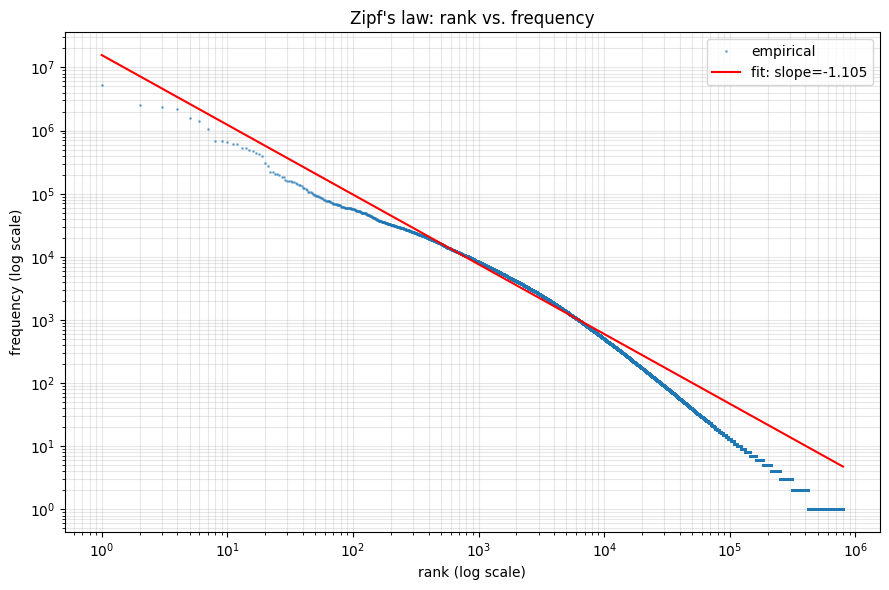

Наклон ≈ -1.105 (Ципф предсказывает ≈ -1)


In [9]:
ranks = np.arange(1, len(freq_df) + 1)
freqs = freq_df['count'].values

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(ranks, freqs, marker='.', linestyle='none', markersize=2, alpha=0.5, label='empirical')
log_r = np.log(ranks)
log_f = np.log(freqs)

# подгоняем по средней части
mask = (ranks >= 10) & (ranks <= 10**4)
slope, intercept = np.polyfit(np.log(ranks[mask]), np.log(freqs[mask]), 1)
ax.loglog(ranks, np.exp(intercept) * ranks ** slope, 'r-', lw=1.5,
          label=f'fit: slope={slope:.3f}')
ax.set_xlabel('rank (log scale)')
ax.set_ylabel('frequency (log scale)')
ax.set_title("Zipf's law: rank vs. frequency")
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Наклон ≈ {slope:.3f} (Ципф предсказывает ≈ -1)')

## 2.4 Закон Хипса

Heaps:   0%|          | 0/369721 [00:00<?, ?it/s]

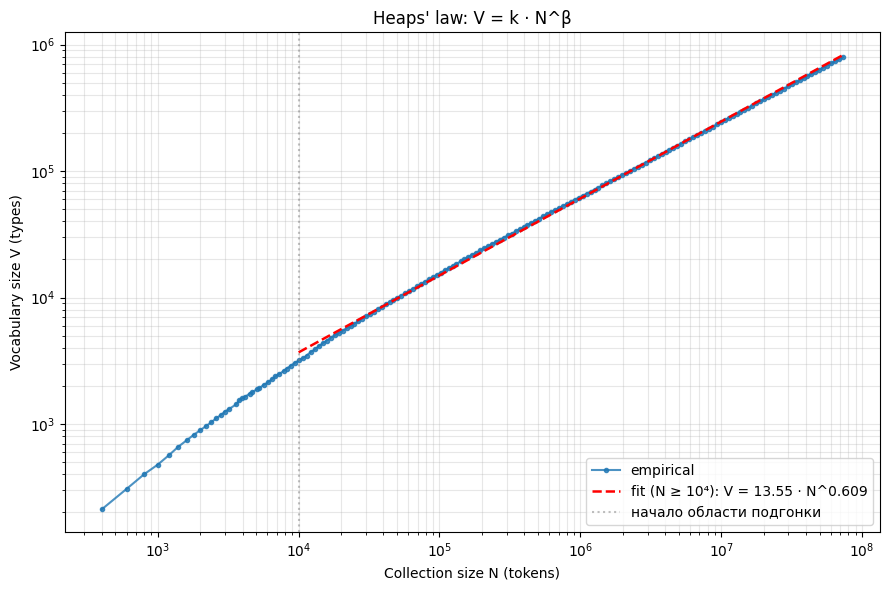

k ≈ 13.55, β ≈ 0.609 (типичные значения: k ∈ [10, 100], β ∈ [0.4, 0.6])


In [11]:
# перемешиваем порядок документов, чтобы возможный тематический порядок
# в исходном CSV не искажал кривую
doc_order = list(range(len(tokenized_docs)))
random.Random(RANDOM_SEED).shuffle(doc_order)

# логарифмически равномерная сетка ~200 точек по индексу документа
n_docs = len(tokenized_docs)
sample_idx = np.unique(
    np.logspace(0, np.log10(n_docs - 1), 200).astype(int)
)
sample_set = set(sample_idx.tolist())
sample_set.add(n_docs - 1)

checkpoints = []
seen = set()
running_tokens = 0
for i, di in enumerate(tqdm(doc_order, desc='Heaps')):
    doc = tokenized_docs[di]
    seen.update(doc)
    running_tokens += len(doc)
    if i in sample_set:
        checkpoints.append((running_tokens, len(seen)))

ck_arr = np.array(checkpoints)
N = ck_arr[:, 0]
V = ck_arr[:, 1]

# подгоняем по средней части кривой
fit_mask = N >= 10**4
b, log_k = np.polyfit(np.log(N[fit_mask]), np.log(V[fit_mask]), 1)
k = math.exp(log_k)

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(N, V, marker='.', linestyle='-', label='empirical', alpha=0.8)
ax.loglog(
    N[fit_mask],
    k * N[fit_mask] ** b,
    'r--', lw=1.8,
    label=f'fit (N ≥ 10⁴): V = {k:.2f} · N^{b:.3f}'
)
ax.axvline(10**4, color='gray', linestyle=':', alpha=0.5,
           label='начало области подгонки')
ax.set_xlabel('Collection size N (tokens)')
ax.set_ylabel('Vocabulary size V (types)')
ax.set_title("Heaps' law: V = k · N^β")
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'k ≈ {k:.2f}, β ≈ {b:.3f} '
      f'(типичные значения: k ∈ [10, 100], β ∈ [0.4, 0.6])')

---
# 3. Частотный список биграмм

## 3.1. Как много уникальных биграмм?

In [14]:
bigram_counter = Counter()
for d in tqdm(tokenized_docs, desc='Биграммы'):
    bigram_counter.update(zip(d, d[1:]))

n_unique_bigrams = len(bigram_counter)
print(f'Уникальных биграмм: {n_unique_bigrams:,}')

Биграммы:   0%|          | 0/369721 [00:00<?, ?it/s]

Уникальных биграмм: 12,993,004


In [16]:
# Top-20 биграмм
top_bigrams = bigram_counter.most_common(20)
bg_df = pd.DataFrame([(f'{a} {b}', c) for (a, b), c in top_bigrams], columns=['bigram', 'count'])
bg_df.head(50)

,bigram,count
0,of the,768320
1,in the,546863
2,to the,256451
3,at the,201351
4,and the,170394
5,on the,169708
6,he was,163554
7,as a,163073
8,for the,159502
9,by the,130810


## 3.2. Какие биграммы стоит держать как отдельные элементы инвертированного индекса?
Идея: pointwise mutual information (PMI). Биграмма "информативна", если её частота сильно выше произведения частот компонентов и при этом она достаточно частотна сама по себе.

In [18]:
MIN_BIGRAM_COUNT = 200
MIN_PMI = 8.0 
MIN_COMPONENT_LEN = 3

total_bigrams = n_tokens - n_docs
total_unigrams = n_tokens

candidates = []
for (w1, w2), c in bigram_counter.items():
    if c < MIN_BIGRAM_COUNT:
        continue
    if len(w1) < MIN_COMPONENT_LEN or len(w2) < MIN_COMPONENT_LEN:
        continue
    if w1 in stop_words or w2 in stop_words:
        continue
    p_bg = c / total_bigrams
    p_w1 = vocab_counter[w1] / total_unigrams
    p_w2 = vocab_counter[w2] / total_unigrams
    pmi = math.log2(p_bg / (p_w1 * p_w2))
    npmi = pmi / (-math.log2(p_bg))
    if pmi < MIN_PMI:
        continue
    candidates.append((f'{w1} {w2}', c, pmi, npmi))

cand_df = pd.DataFrame(candidates, columns=['bigram', 'count', 'PMI', 'NPMI'])
cand_df = cand_df.sort_values('NPMI', ascending=False).reset_index(drop=True)
print(f'Кандидатов в словарь биграмм: {len(cand_df)}')
cand_df.head(40)

Кандидатов в словарь биграмм: 1526


,bigram,count,PMI,NPMI
0,buenos aires,1375,15.673005,0.998871
1,rodr guez,473,17.199598,0.998222
2,hong kong,4851,13.630404,0.982594
3,cum laude,1017,15.833466,0.981870
4,los angeles,10042,12.575695,0.980777
5,kuala lumpur,421,17.054227,0.980226
6,atl tico,539,16.692401,0.979498
7,gonz lez,534,16.662623,0.976980
8,sup rieure,273,17.538295,0.973097
9,notre dame,1244,15.377912,0.971125


---
# 4. Морфологическая обработка

Сравниваем три подхода: Porter stemmer (NLTK), spaCy lemmatizer, BERT WordPiece tokenizer.

## 4.1. Porter stemmer

In [20]:
stemmer = PorterStemmer()
stem_cached = lru_cache(maxsize=None)(stemmer.stem)

stemmed_vocab = Counter()
stemmed_doc_lens = []

for d in tqdm(tokenized_docs, desc='Porter'):
    stems = [stem_cached(t) for t in d]
    stemmed_vocab.update(stems)
    stemmed_doc_lens.append(len(stems))

stem_n_types = len(stemmed_vocab)
stem_total = sum(stemmed_vocab.values())
stem_avg_doc = np.mean(stemmed_doc_lens)
stem_avg_token_len = sum(len(w) * c for w, c in stemmed_vocab.items()) / stem_total
stem_avg_type_len = sum(len(w) for w in stemmed_vocab) / stem_n_types
print('Porter:', dict(types=stem_n_types, tokens=stem_total,
                       avg_doc=round(stem_avg_doc, 2),
                       avg_tok_len=round(stem_avg_token_len, 3),
                       avg_type_len=round(stem_avg_type_len, 3)))

Porter:   0%|          | 0/369721 [00:00<?, ?it/s]

Porter: {'types': 684579, 'tokens': 73093729, 'avg_doc': np.float64(197.7), 'avg_tok_len': 4.265, 'avg_type_len': 7.342}


## 4.2. spaCy

In [28]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

lemma_vocab = Counter()
lemma_doc_lens = []
BATCH = 256

def doc_stream(docs_tokens):
    for d in docs_tokens:
        yield Doc(nlp.vocab, words=d)

for doc in tqdm(
    nlp.pipe(doc_stream(tokenized_docs), batch_size=BATCH),
    total=len(tokenized_docs),
    desc='spaCy'
):
    lemmas = [tok.lemma_.lower() for tok in doc]
    lemma_vocab.update(lemmas)
    lemma_doc_lens.append(len(lemmas))

lem_n_types = len(lemma_vocab)
lem_total = sum(lemma_vocab.values())
lem_avg_doc = np.mean(lemma_doc_lens)
lem_avg_token_len = sum(len(w) * c for w, c in lemma_vocab.items()) / lem_total
lem_avg_type_len = sum(len(w) for w in lemma_vocab) / lem_n_types

print('spaCy:', dict(types=lem_n_types, tokens=lem_total,
                      avg_doc=round(lem_avg_doc, 2),
                      avg_tok_len=round(lem_avg_token_len, 3),
                      avg_type_len=round(lem_avg_type_len, 3)))

spaCy:   0%|          | 0/369721 [00:00<?, ?it/s]

spaCy: {'types': 760242, 'tokens': 73093729, 'avg_doc': np.float64(197.7), 'avg_tok_len': 4.587, 'avg_type_len': 7.63}


## 4.3. BERT's tokenizer

In [30]:
bert_tok = AutoTokenizer.from_pretrained('bert-base-uncased')

bert_vocab = Counter()
bert_doc_lens = []
for d in tqdm(tokenized_docs, desc='BERT'):
    pieces = bert_tok.tokenize(' '.join(d))
    bert_vocab.update(pieces)
    bert_doc_lens.append(len(pieces))

bert_n_types = len(bert_vocab)
bert_total = sum(bert_vocab.values())
bert_avg_doc = np.mean(bert_doc_lens)
bert_avg_token_len = sum(len(w) * c for w, c in bert_vocab.items()) / bert_total
bert_avg_type_len = sum(len(w) for w in bert_vocab) / bert_n_types
print('BERT:', dict(types=bert_n_types, tokens=bert_total,
                     avg_doc=round(bert_avg_doc, 2),
                     avg_tok_len=round(bert_avg_token_len, 3),
                     avg_type_len=round(bert_avg_type_len, 3)))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BERT:   0%|          | 0/369721 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (785 > 512). Running this sequence through the model will result in indexing errors


BERT: {'types': 27528, 'tokens': 81185427, 'avg_doc': np.float64(219.59), 'avg_tok_len': 4.517, 'avg_type_len': 6.634}


## 4.4. Сравнение

In [ ]:
comparison = pd.DataFrame({
    'raw':    [n_docs, n_tokens, n_types, avg_doc_len, avg_token_len, avg_type_len],
    'porter': [n_docs, stem_total, stem_n_types, stem_avg_doc, stem_avg_token_len, stem_avg_type_len],
    'spacy':  [n_docs, lem_total, lem_n_types, lem_avg_doc, lem_avg_token_len, lem_avg_type_len],
    'bert':   [n_docs, bert_total, bert_n_types, bert_avg_doc, bert_avg_token_len, bert_avg_type_len],
}, index=['# docs', '# tokens', '# types', 'avg doc len', 'avg token len', 'avg type len'])
comparison.loc['vocab compression'] = [
    1.0,
    stem_n_types / n_types,
    lem_n_types / n_types,
    bert_n_types / n_types,
]
comparison.style.format('{:,.0f}', subset=pd.IndexSlice[['# docs', '# tokens', '# types'], :]) \
                .format('{:.3f}', subset=pd.IndexSlice[['avg doc len', 'avg token len', 'avg type len'], :])

,raw,porter,spacy,bert
# docs,"369,721","369,721","369,721","369,721"
# tokens,"73,093,729","73,093,729","73,093,729","81,185,427"
# types,"794,568","684,579","760,242","27,528"
avg doc len,197.700,197.700,197.700,219.586
avg token len,4.795,4.265,4.587,4.517
avg type len,7.714,7.342,7.630,6.634
vocab compression,1.000000,0.861574,0.956799,0.034645


In [32]:
# Примеры конкретных слов
test_words = ['running', 'better', 'mice', 'studies', 'organization', 'unbelievable']
for w in test_words:
    print(f'{w:20s}  porter={stemmer.stem(w):15s}  '
          f'spacy={nlp(w)[0].lemma_:15s}  '
          f'bert={bert_tok.tokenize(w)}')

running               porter=run              spacy=run              bert=['running']
better                porter=better           spacy=well             bert=['better']
mice                  porter=mice             spacy=mouse            bert=['mice']
studies               porter=studi            spacy=study            bert=['studies']
organization          porter=organ            spacy=organization     bert=['organization']
unbelievable          porter=unbeliev         spacy=unbelievable     bert=['unbelievable']


---
# Дополнительные задания

## 1. Толстой и Достоевский

### 1.1. Загрузка и предобработка текстов

In [39]:
FB2_NS = '{http://www.gribuser.ru/xml/fictionbook/2.1}'

def read_fb2(path):
    tree = ET.parse(path)
    root = tree.getroot()
    paragraphs = []
    for body in root.findall(f'{FB2_NS}body'):
        if body.get('name') in ('notes', 'comments'):
            continue
        for p in body.iter(f'{FB2_NS}p'):
            text = ''.join(p.itertext()).strip()
            if text:
                paragraphs.append(text)

    return '\n'.join(paragraphs)


def read_fb2_many(paths):
    texts = []
    for p in paths:
        try:
            t = read_fb2(p)
            print(f'{p.split('/')[-1]}: {len(t):,} символов, {t.count(chr(10))+1} абзацев')
            texts.append(t)
        except ET.ParseError as e:
            print(f'Ошибка парсинга {p}: {e}')
    return texts


data_dir = '/kaggle/input/datasets/hemulitch/tolstoy-dostoevsky'
tolstoy_paths = sorted([f'{data_dir}/{f}' for f in os.listdir(data_dir) if f.startswith('tolstoj')])
dost_paths    = sorted([f'{data_dir}/{f}' for f in os.listdir(data_dir) if f.startswith('dostoewskij')])

print(f'Файлов Толстого:    {len(tolstoy_paths)}')
print(f'Файлов Достоевского: {len(dost_paths)}')

tolstoy_texts = read_fb2_many(tolstoy_paths)
dost_texts    = read_fb2_many(dost_paths)

print()
print(f'Толстой:     {sum(len(t) for t in tolstoy_texts):,} символов')
print(f'Достоевский: {sum(len(t) for t in dost_texts):,} символов')

Файлов Толстого:    4
Файлов Достоевского: 4
tolstoj_lew_nikolaewich-text_0040.fb2: 723,330 символов, 3513 абзацев
tolstoj_lew_nikolaewich-text_0050.fb2: 756,990 символов, 3135 абзацев
tolstoj_lew_nikolaewich-text_0060.fb2: 813,822 символов, 3218 абзацев
tolstoj_lew_nikolaewich-text_0070.fb2: 1,310,814 символов, 11529 абзацев
dostoewskij_f_m-text_0100.fb2: 375,330 символов, 994 абзацев
dostoewskij_f_m-text_0110.fb2: 395,235 символов, 927 абзацев
dostoewskij_f_m-text_0120.fb2: 428,588 символов, 1541 абзацев
dostoewskij_f_m-text_0130.fb2: 622,791 символов, 1801 абзацев

Толстой:     3,604,956 символов
Достоевский: 1,821,944 символов


In [44]:
nlp = spacy.load('ru_core_news_sm', disable=['parser', 'ner'])
nlp.max_length = 1_500_000

In [45]:
RU_TOKEN = re.compile(r'^[а-яё]{2,}$')

def lemmatize_ru(texts, batch_size=256):
    parts = []
    lemmas = []
    for doc in tqdm(nlp.pipe(texts, batch_size=batch_size),
                    total=len(parts), desc='spaCy'):
        for tok in doc:
            lemma = tok.lemma_.lower()
            if RU_TOKEN.match(lemma):
                lemmas.append(lemma)
    return lemmas


tol_tokens  = lemmatize_ru(tolstoy_texts)
dost_tokens = lemmatize_ru(dost_texts)

spaCy: 0it [00:00, ?it/s]

spaCy: 0it [00:00, ?it/s]

In [48]:
print('Толстой токенов:', len(tol_tokens), '| уникальных:', len(set(tol_tokens)))
print('Достоевский токенов:', len(dost_tokens), '| уникальных:', len(set(dost_tokens)))

Толстой токенов: 457575 | уникальных: 26968
Достоевский токенов: 259107 | уникальных: 19882


### 1.2 Характерные слова: log-ratio со сглаживанием Лапласа

В токенах встречается много "мусора", засоряющего выдачу в этом задании, поэтому мы их уберем (это издательские пометки и сноски которые при чтении и парсинге были добавлены в основной текст)

In [61]:
META_TOKENS = {
    'стр',          # стр. 247
    'строка',       # строка 12
    'изд',          # изд. 1869
    'сноска',
    'сноске',
    'гл',           # гл. III
    'глава',        # как ссылка, не как заголовок главы
    'том',          # т. 4
    'кн',           # кн. 2
    'книга',        # как ссылка
    # Редакторские маркеры
    'ред',          # ред. примечание
    'примеч',
    'примечание',
    'см',           # см. далее
    'ср',           # ср. с
    'ст',           # ст. (статья / стих)
    'вып',          # выпуск
    'отд',          # отдел
    # Сокращения, обычные в комментариях
    'ч',            # ч. 1, ч. 2
    'чт',           # сокращение от "что", артефакт лемматизации
}

tol_tokens  = [t for t in tol_tokens  if t not in META_TOKENS]
dost_tokens = [t for t in dost_tokens if t not in META_TOKENS]

print(f'После очистки:')
print(f'  Толстой:     {len(tol_tokens):,} токенов | уникальных: {len(set(tol_tokens)):,}')
print(f'  Достоевский: {len(dost_tokens):,} токенов | уникальных: {len(set(dost_tokens)):,}')

После очистки:
  Толстой:     445,704 токенов | уникальных: 26,956
  Достоевский: 258,766 токенов | уникальных: 19,878


In [62]:
tol_c  = Counter(tol_tokens)
dost_c = Counter(dost_tokens)
Nt_total = sum(tol_c.values())
Nd_total = sum(dost_c.values())
ALPHA = 1.0

vocab_all = set(tol_c) | set(dost_c)
rows = []
for w in vocab_all:
    a = tol_c.get(w, 0); b = dost_c.get(w, 0)
    if a + b < 30:
        continue
    pa = (a + ALPHA) / (Nt_total + ALPHA * len(vocab_all))
    pb = (b + ALPHA) / (Nd_total + ALPHA * len(vocab_all))
    log_ratio = math.log(pa / pb)
    rows.append((w, a, b, log_ratio))

char_df = pd.DataFrame(rows, columns=['word', 'tolstoy', 'dostoevsky', 'log_ratio'])
print(f'Слов после порога частоты ≥30: {len(char_df):,}')

print('\nХарактерные для Толстого:')
print(char_df.sort_values('log_ratio', ascending=False).head(20).to_string(index=False))
print('\nХарактерные для Достоевского:')
print(char_df.sort_values('log_ratio').head(20).to_string(index=False))

Слов после порога частоты ≥30: 2,538

Характерные для Толстого:
    word  tolstoy  dostoevsky  log_ratio
    пьер     2507           0   7.337542
  ростов     1014           0   6.432945
  княжна      730           0   6.104715
  войско      619           0   5.940021
   князь     2473           3   5.937598
сражение      553           0   5.827466
 денисов      551           0   5.823849
 графиня      506           0   5.738812
    соня      488           0   5.702664
  наташа     1262           2   5.552934
   борис      403           0   5.511716
    граф      803           1   5.506753
 кутузов      674           1   5.331867
адъютант      295           0   5.200661
 анатоль      277           0   5.137922
наполеон      757           2   5.042372
 долохов      243           0   5.007469
 василий      243           0   5.007469
    петя      236           0   4.978361
    элен      206           0   4.843020

Характерные для Достоевского:
      word  tolstoy  dostoevsky  log_ratio
 

Самые частоупотребляемые из уникальных - имена героев обоих произведений.

Стоп-слова при обработке не убирались, потому что у обоих авторов они одинаково часто встречаются

In [52]:
print('\nТоп-30 Толстой:')
for w, c in tol_c.most_common(30):
    print(f'  {w:15s} {c:>7,}')

print('\nТоп-30 Достоевский:')
for w, c in dost_c.most_common(30):
    print(f'  {w:15s} {c:>7,}')


Топ-30 Толстой:
  он                9,830
  не                9,586
  на                7,551
  что               7,466
  быть              5,339
  как               4,568
  это               3,902
  она               3,679
  сказать           3,679
  стр               3,513
  строка            3,511
  то                3,414
  свой              3,331
  но                2,984
  вместо            2,935
  этот              2,894
  изд               2,744
  весь              2,695
  его               2,656
  пьер              2,507
  тот               2,497
  князь             2,473
  по                2,404
  говорить          2,305
  было              2,292
  за                2,160
  так               2,158
  из                2,119
  человек           2,110
  от                1,976

Топ-30 Достоевский:
  не                6,874
  что               6,354
  он                4,787
  на                3,703
  быть              3,285
  то                3,079
  это               3,052


### 1.3. Кривые роста словаря (Heaps' law)


Текст                            k        β
Толстой (orig)                7.58    0.634
Толстой (shuf)               10.27    0.616
Достоевский (orig)            5.71    0.664
Достоевский (shuf)            8.18    0.635


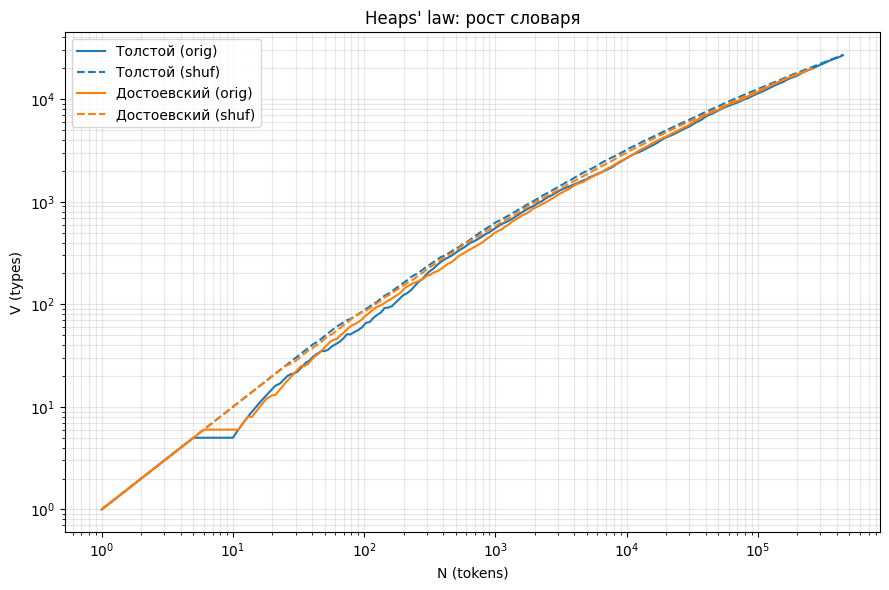

In [67]:
def vocab_growth(tokens, n_points=200):
    n = len(tokens)
    sample_idx = set(np.unique(np.logspace(0, np.log10(n - 1), n_points).astype(int)).tolist())
    sample_idx.add(n)
    seen = set()
    Ns, Vs = [], []
    for i, t in enumerate(tokens, 1):
        seen.add(t)
        if i in sample_idx:
            Ns.append(i); Vs.append(len(seen))
    return np.array(Ns), np.array(Vs)
    
def fit_heaps(N, V, n_min=1000):
    mask = N >= n_min
    b, log_k = np.polyfit(np.log(N[mask]), np.log(V[mask]), 1)
    return math.exp(log_k), b


rng = random.Random(42)
tol_shuf  = tol_tokens.copy();  rng.shuffle(tol_shuf)
dost_shuf = dost_tokens.copy(); rng.shuffle(dost_shuf)

curves = {
    'Толстой (orig)':     vocab_growth(tol_tokens),
    'Толстой (shuf)':     vocab_growth(tol_shuf),
    'Достоевский (orig)': vocab_growth(dost_tokens),
    'Достоевский (shuf)': vocab_growth(dost_shuf),
}

print(f'\n{"Текст":25s}  {"k":>7s}  {"β":>7s}')
for name, (N, V) in curves.items():
    k, b = fit_heaps(N, V)
    print(f'{name:25s}  {k:7.2f}  {b:7.3f}')

fig, ax = plt.subplots(figsize=(9, 6))
styles = {'orig': '-', 'shuf': '--'}
colors = {'Толстой': 'C0', 'Достоевский': 'C1'}
for name, (N, V) in curves.items():
    author = name.split()[0]
    kind = 'orig' if 'orig' in name else 'shuf'
    ax.loglog(N, V, styles[kind], color=colors[author], label=name)
ax.set_xlabel('N (tokens)')
ax.set_ylabel('V (types)')
ax.set_title("Heaps' law: рост словаря")
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Детекция машинно-сгенерированных текстов (CoAT)

### 2.1. Загрузка и обработка данных

In [64]:
! git clone https://github.com/RussianNLP/CoAT

Cloning into 'CoAT'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 24 (delta 4), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 10.40 KiB | 3.46 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Filtering content: 100% (6/6), 259.34 MiB | 22.73 MiB/s, done.


In [82]:
COAT_DIR = '/kaggle/working/CoAT/datasets/binary'
test = pd.read_csv(f'{COAT_DIR}/test.csv')
train = pd.read_csv(f'{COAT_DIR}/train.csv')
val = pd.read_csv(f'{COAT_DIR}/val.csv')

In [78]:
RU_STOPWORDS = set(stopwords.words('russian'))

def tokenize(text):
    doc = nlp(text)
    return [tok.lemma_.lower() for tok in doc if RU_TOKEN.fullmatch(tok.lemma_.lower())]
    
def coat_features(toks):
    n = len(toks)
    if n == 0:
        return [0]*9
    if n == 1:
        return [1, 1, len(toks[0]), 0.0, 1.0, 1.0, 
                float(toks[0] in RU_STOPWORDS), 0.0, 0.0]

    types_set = set(toks)
    v = len(types_set)
    lens = [len(t) for t in toks]
    cnt = Counter(toks)

    # Базовые
    avg_len = float(np.mean(lens))
    std_len = float(np.std(lens))
    ttr = v / n
    hapax = sum(1 for c in cnt.values() if c == 1) / v
    sw = sum(1 for t in toks if t in RU_STOPWORDS) / n

    # Heaps β для одного текста
    seen = set()
    Ns, Vs = [], []
    step = max(1, n // 30)
    for i, t in enumerate(toks, 1):
        seen.add(t)
        if i % step == 0 or i == n:
            Ns.append(i); Vs.append(len(seen))
    Ns, Vs = np.array(Ns), np.array(Vs)
    if n < 50:
        beta = 0.0
    elif len(Ns) >= 3 and Vs[-1] > 1:
        beta, _ = np.polyfit(np.log(Ns), np.log(Vs), 1)
    else:
        beta = 0.0

    # Zipf slope
    if v >= 20:
        freqs = sorted(cnt.values(), reverse=True)
        ranks = np.arange(1, len(freqs) + 1)
        slope, _ = np.polyfit(np.log(ranks), np.log(freqs), 1)
    else:
        slope = 0.0

    return [n, v, avg_len, std_len, ttr, hapax, sw, float(beta), float(slope)]

In [84]:
def process(X):
    toks = []
    for text in tqdm(X, total=len(X)):
        toks.append(tokenize(text))
    stats = []
    for tok in toks:
        stats.append(coat_features(tok))
    return toks, stats

train_sample, _ = train_test_split(
    train, train_size=50_000,
    stratify=train['label'], random_state=42
)
test_sample, _ = train_test_split(
    val, train_size=10_000,
    stratify=val['label'], random_state=42
)

X_train = train_sample['text'].tolist()
y_train = train_sample['label'].values
X_test = test_sample['text'].tolist()
y_test = test_sample['label'].values

train_tokens, train_stats = process(X_train)
test_tokens, test_stats = process(X_test)

  0%|          | 0/50000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [85]:
train_stats = np.array(train_stats)
test_stats = np.array(test_stats)
train_stats = np.nan_to_num(train_stats, nan=0.0, posinf=0.0, neginf=0.0)
test_stats  = np.nan_to_num(test_stats,  nan=0.0, posinf=0.0, neginf=0.0)

In [86]:
# у нас признаки разного масштаба, поэтому делаем скейлинг
scaler = StandardScaler()
train_stats_scaled = scaler.fit_transform(train_stats)
test_stats_scaled  = scaler.transform(test_stats)

In [87]:
# дополняем признаками из текстов
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=100_000,
                      sublinear_tf=True)
train_tfidf = vec.fit_transform(X_train)
test_tfidf  = vec.transform(X_test)

X_tr = hstack([train_tfidf, csr_matrix(train_stats_scaled)])
X_te = hstack([test_tfidf,  csr_matrix(test_stats_scaled)])

In [88]:
clf = LogisticRegression(max_iter=5000, C=1.0, n_jobs=-1).fit(X_tr, y_train)
preds = clf.predict(X_te)
print(classification_report(y_test, preds, digits=3))

              precision    recall  f1-score   support

           0      0.694     0.740     0.717      5000
           1      0.722     0.674     0.697      5000

    accuracy                          0.707     10000
   macro avg      0.708     0.707     0.707     10000
weighted avg      0.708     0.707     0.707     10000

